<a href="https://colab.research.google.com/github/Muqqadas30/fsdl-my-labs/blob/main/lab03/lab03_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
import matplotlib.pyplot as plt

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


In [2]:
train_raw = datasets.FashionMNIST(root="./data", train=True, download=True)
valid_raw = datasets.FashionMNIST(root="./data", train=False, download=True)

x_train = train_raw.data.float().unsqueeze(1) / 255.0
y_train = train_raw.targets
x_valid = valid_raw.data.float().unsqueeze(1) / 255.0
y_valid = valid_raw.targets

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

class FashionDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = FashionDataset(x_train, y_train)
valid_ds = FashionDataset(x_valid, y_valid)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.5MB/s]


In [3]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)          # 28x28 -> 14x14
        x = F.relu(self.conv2(x))
        x = self.pool(x)          # 14x14 -> 7x7
        return x                  # shape: (batch, 32, 7, 7)

In [4]:
def to_sequence(feature_map):
    # feature_map shape: (batch, channels, H, W)
    batch, channels, h, w = feature_map.shape
    seq = feature_map.reshape(batch, channels, h * w)   # (batch, channels, 49)
    seq = seq.permute(0, 2, 1)                          # (batch, 49, channels) -- sequence format
    return seq

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

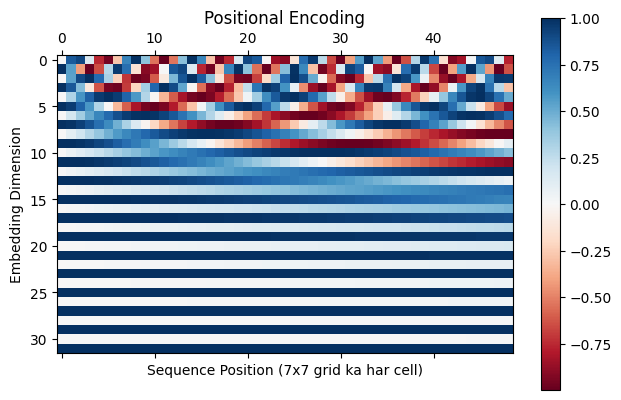

In [6]:
pos_enc = PositionalEncoding(d_model=32, max_len=49)
plt.matshow(pos_enc.pe.squeeze().T, cmap="RdBu")
plt.xlabel("Sequence Position (7x7 grid ka har cell)")
plt.ylabel("Embedding Dimension")
plt.title("Positional Encoding")
plt.colorbar()
plt.show()

In [7]:
class CNNTransformerClassifier(nn.Module):
    def __init__(self, num_classes=10, d_model=32, nhead=4, num_layers=2):
        super().__init__()
        self.cnn_encoder = CNNEncoder()
        self.pos_encoding = PositionalEncoding(d_model=d_model, max_len=49)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=64, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        features = self.cnn_encoder(x)              # CNN se features nikalna
        seq = to_sequence(features)                  # sequence mein convert karna
        seq = self.pos_encoding(seq)                 # position info add karna

        transformed = self.transformer_encoder(seq)  # self-attention apply karna

        pooled = transformed.mean(dim=1)              # sab positions ka average -- final representation
        out = self.classifier(pooled)
        return out

model = CNNTransformerClassifier().to(device)
print(model)

CNNTransformerClassifier(
  (cnn_encoder): CNNEncoder(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pos_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2

In [11]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 22,218


Attention shape: torch.Size([1, 49, 49])


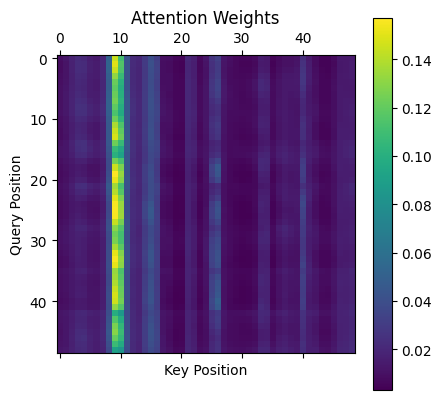

In [13]:
model.eval()
sample = x_valid[0:1].to(device)

with torch.no_grad():
    features = model.cnn_encoder(sample)
    seq = to_sequence(features)
    seq = model.pos_encoding(seq)

    attn_layer = model.transformer_encoder.layers[0].self_attn
    attn_output, attn_weights = attn_layer(seq, seq, seq, need_weights=True, average_attn_weights=True)

print("Attention shape:", attn_weights.shape)

plt.matshow(attn_weights[0].cpu().numpy(), cmap="viridis")
plt.title("Attention Weights")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.colorbar()
plt.show()